In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib and Seaborn style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)

# Load cleaned dataset from File 2
data_path = os.path.join('data', 'all_months_clean.csv')

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f" Cleaned dataset loaded successfully. Shape: {df.shape}")
else:
    raise FileNotFoundError(f"File not found at '{data_path}'. Run 02_Data_Cleaning_and_Standardization first.")

 Cleaned dataset loaded successfully. Shape: (798, 55)


In [12]:
# Separate numerical, categorical, and district columns
price_cols = ['Min_Price', 'Max_Price', 'Avg_Price']
supply_cols = ['Volume', 'TOTAL_sources', 'reconciliation_gap', 'import_share']
meta_cols = ['Product_Name', 'Category', 'month_name', 'month_idx', 'bs_year', 'bs_month']

district_cols = [c for c in df.columns if c not in price_cols + supply_cols + meta_cols + ['Unit', 'unit_canonical', 'unit_changed', 'Total_Amount', 'Volume_Equals', 'n_months_present', 'is_balanced']]

print("=== SUMMARY STATISTICS FOR PRICES ===")
display(df[price_cols].describe())

print("\n=== SUMMARY STATISTICS FOR SUPPLY VOLUMES ===")
display(df[supply_cols].describe())

print("\n=== MISSING VALUES PROFILE ===")
print(df[price_cols + supply_cols].isnull().sum())

=== SUMMARY STATISTICS FOR PRICES ===


,Min_Price,Max_Price,Avg_Price
count,721.000000,722.000000,798.000000
mean,127.059639,196.783934,157.646717
std,99.368551,152.792964,116.014335
min,10.000000,35.000000,26.360000
25%,60.000000,100.000000,78.065000
50%,100.000000,150.000000,116.800000
75%,160.000000,250.000000,201.297500
max,700.000000,1200.000000,757.610000



=== SUMMARY STATISTICS FOR SUPPLY VOLUMES ===


,Volume,TOTAL_sources,reconciliation_gap,import_share
count,7.980000e+02,7.980000e+02,7.980000e+02,713.000000
mean,8.983439e+04,9.289258e+04,-3.058192e+03,0.420377
std,1.486036e+05,1.591914e+05,5.344007e+04,0.435332
min,0.000000e+00,0.000000e+00,-1.357613e+06,0.000000
25%,4.782500e+03,4.827500e+03,0.000000e+00,0.000000
50%,3.548500e+04,3.572700e+04,0.000000e+00,0.247898
75%,1.251288e+05,1.256910e+05,0.000000e+00,0.986495
max,1.757370e+06,1.757370e+06,6.722600e+04,1.000000



=== MISSING VALUES PROFILE ===
Min_Price             77
Max_Price             76
Avg_Price              0
Volume                 0
TOTAL_sources          0
reconciliation_gap     0
import_share          85
dtype: int64


In [13]:
# Aggregate average price and total volume by Product
product_summary = df.groupby('Product_Name').agg(
    Avg_Price=('Avg_Price', 'mean'),
    Total_Volume=('Volume', 'sum'),
    Import_Share=('import_share', 'mean'),
    Category=('Category', 'first'),
    Months_Present=('month_idx', 'nunique')
).reset_index()

print(" Top 10 Most Supplied Products by Volume:")
display(product_summary.sort_values(by='Total_Volume', ascending=False).head(10))

print("\n Top 10 Highest Price Products (Avg NPR):")
display(product_summary.sort_values(by='Avg_Price', ascending=False).head(10))

 Top 10 Most Supplied Products by Volume:


,Product_Name,Avg_Price,Total_Volume,Import_Share,Category,Months_Present
90,Tomato_Small,69.857000,6599144,0.257812,vegetable,0
66,Potato_R,37.224444,4232377,0.595299,vegetable,0
2,Apple,251.637000,3641603,0.899575,fruit,0
93,Watermelon,66.576000,3482230,0.972574,fruit,0
53,Onion_Dry,45.824000,3439846,0.900000,vegetable,0
9,Banana_Green,163.927000,3085375,0.581394,fruit,0
19,Cabbage,52.792000,3039724,0.022868,vegetable,0
22,Cauliflower_Hill,88.505000,2678920,0.046850,vegetable,0
29,Cucumber,92.844000,2361283,0.176669,vegetable,0
55,Orange,165.965000,2312325,0.626819,fruit,0



 Top 10 Highest Price Products (Avg NPR):


,Product_Name,Avg_Price,Total_Volume,Import_Share,Category,Months_Present
83,Strawberry,571.618333,7390,1.000000,fruit,0
0,Akabary_Chilly,514.780000,21110,0.294205,vegetable,0
92,Walnut,450.000000,1660,1.000000,fruit,0
45,Kurilo,439.953750,511,0.000000,vegetable,0
5,Avocado,415.404000,72469,0.788299,fruit,0
74,Red_Grapes,414.817500,8840,1.000000,fruit,0
44,Kiwi,389.895000,60930,0.871874,fruit,0
30,Dragon_Fruits,345.999000,78314,0.818140,fruit,0
41,Haluwabed,327.187500,62190,1.000000,fruit,0
36,Grapes,321.357000,905435,1.000000,fruit,0


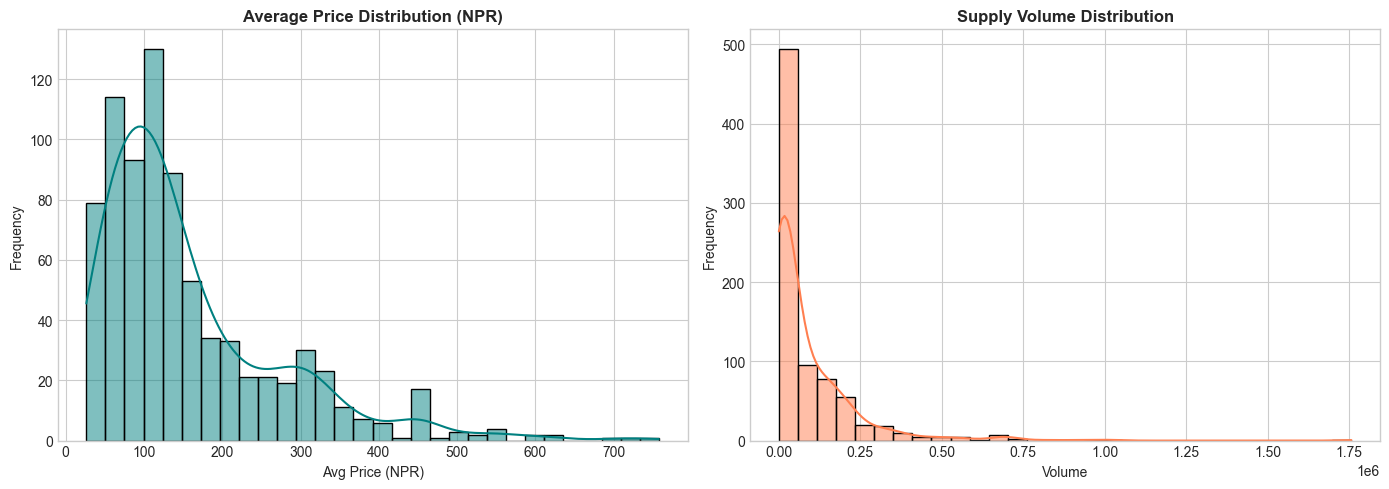

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution (Log scale due to skewness)
sns.histplot(df['Avg_Price'].dropna(), kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Average Price Distribution (NPR)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Price (NPR)')
axes[0].set_ylabel('Frequency')

# Volume distribution
sns.histplot(df['Volume'].dropna(), kde=True, ax=axes[1], color='coral', bins=30)
axes[1].set_title('Supply Volume Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volume')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

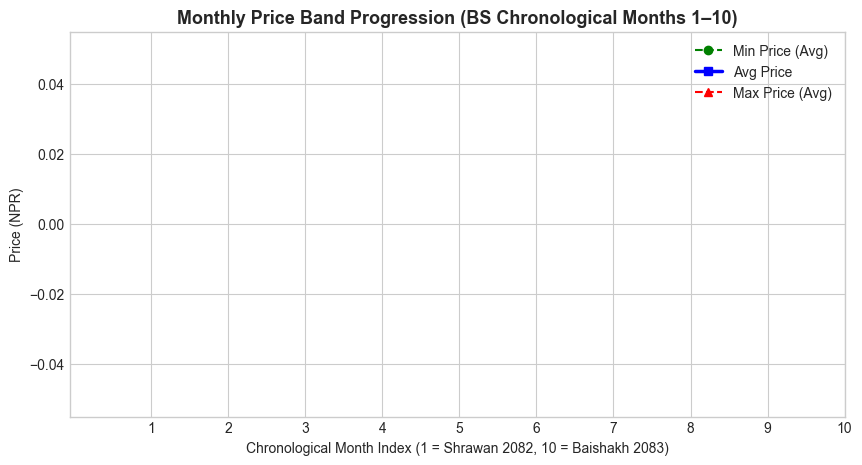

In [15]:
plt.figure(figsize=(10, 5))

# Plot mean Min, Avg, and Max prices across chronological months
monthly_price = df.groupby('month_idx')[['Min_Price', 'Avg_Price', 'Max_Price']].mean()

plt.plot(monthly_price.index, monthly_price['Min_Price'], label='Min Price (Avg)', marker='o', linestyle='--', color='green')
plt.plot(monthly_price.index, monthly_price['Avg_Price'], label='Avg Price', marker='s', linewidth=2.5, color='blue')
plt.plot(monthly_price.index, monthly_price['Max_Price'], label='Max Price (Avg)', marker='^', linestyle='--', color='red')

plt.title('Monthly Price Band Progression (BS Chronological Months 1–10)', fontsize=13, fontweight='bold')
plt.xlabel('Chronological Month Index (1 = Shrawan 2082, 10 = Baishakh 2083)')
plt.ylabel('Price (NPR)')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()

/var/folders/7g/ncvyfv3n01gds4p5h1m65g0w0000gn/T/ipykernel_15976/561370176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Avg_Price', palette='Set2')


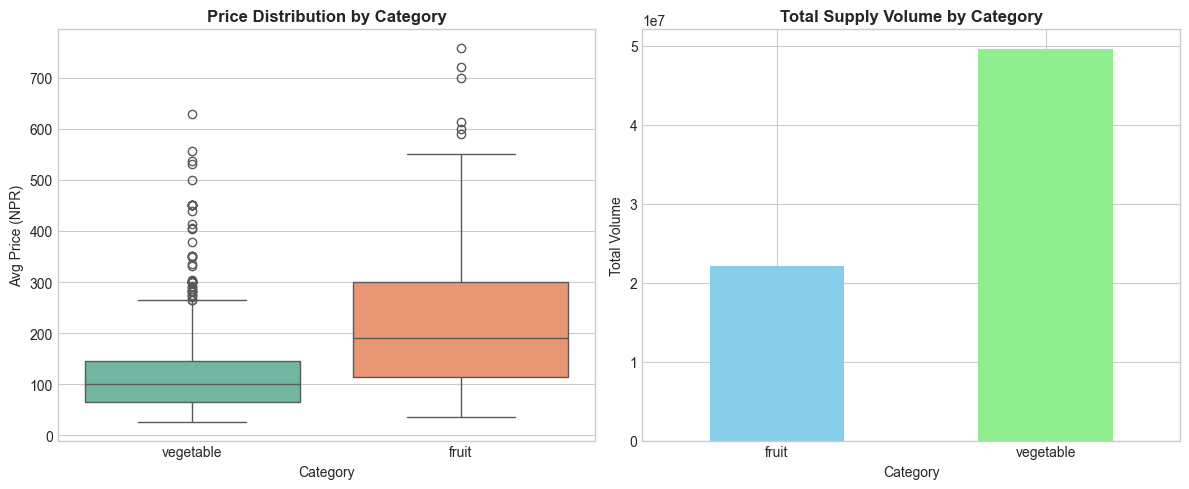

In [16]:
plt.figure(figsize=(12, 5))

# Category average prices
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Category', y='Avg_Price', palette='Set2')
plt.title('Price Distribution by Category', fontweight='bold')
plt.ylabel('Avg Price (NPR)')

# Category total volume
plt.subplot(1, 2, 2)
df.groupby('Category')['Volume'].sum().plot(kind='bar', color=['skyblue', 'lightgreen', 'orange'])
plt.title('Total Supply Volume by Category', fontweight='bold')
plt.ylabel('Total Volume')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

/var/folders/7g/ncvyfv3n01gds4p5h1m65g0w0000gn/T/ipykernel_15976/2838014758.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_districts.values, y=top_districts.index, palette='viridis')


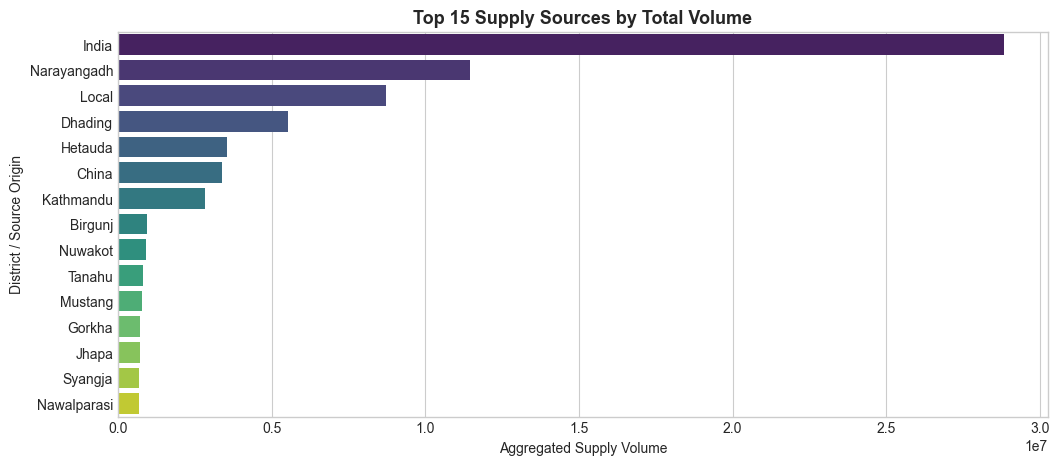

In [17]:
# Identify top 15 supply source districts/origins overall
top_districts = df[district_cols].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_districts.values, y=top_districts.index, palette='viridis')
plt.title('Top 15 Supply Sources by Total Volume', fontsize=13, fontweight='bold')
plt.xlabel('Aggregated Supply Volume')
plt.ylabel('District / Source Origin')
plt.show()

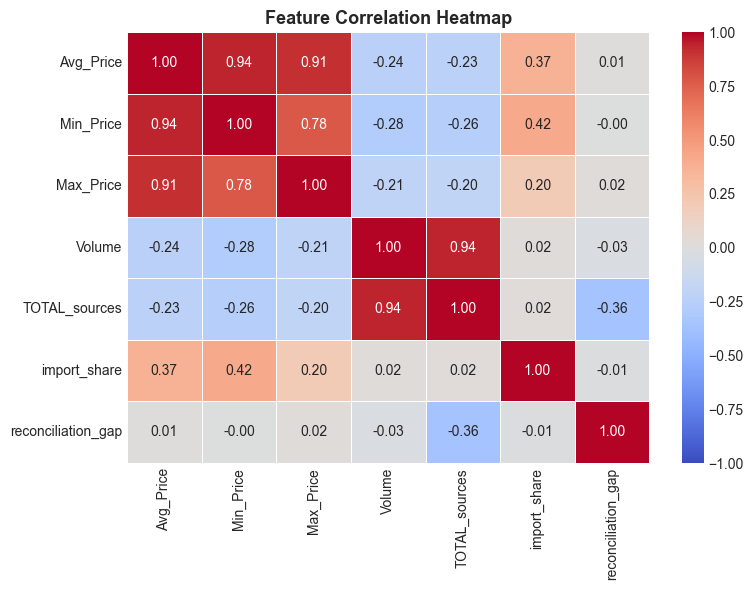

In [18]:
plt.figure(figsize=(8, 6))

corr_features = ['Avg_Price', 'Min_Price', 'Max_Price', 'Volume', 'TOTAL_sources', 'import_share', 'reconciliation_gap']
corr_matrix = df[corr_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
print("=== BALANCED PANEL AUDIT SUMMARY ===")
print(f"Total Unique Products: {df['Product_Name'].nunique()}")
print(f"Balanced Products (Present in all 10 Months): {df[df['is_balanced']]['Product_Name'].nunique()}")
print(f"Unbalanced Products (<10 Months): {df[~df['is_balanced']]['Product_Name'].nunique()}")

print("\n Unbalanced Products Breakdown:")
display(df[~df['is_balanced']].groupby('Product_Name')['month_idx'].nunique().reset_index().rename(columns={'month_idx': 'Months_Recorded'}))

=== BALANCED PANEL AUDIT SUMMARY ===
Total Unique Products: 95
Balanced Products (Present in all 10 Months): 0
Unbalanced Products (<10 Months): 95

 Unbalanced Products Breakdown:


,Product_Name,Months_Recorded
0,Akabary_Chilly,0
1,Amala,0
2,Apple,0
3,Apple_Fuji,0
4,Arum,0
...,...,...
90,Tomato_Small,0
91,Turnip,0
92,Walnut,0
93,Watermelon,0
